# PHQ-8 Depression Detection — CNN + LSTM (Regression)

**Architecture**: 2 convolutional blocks reduce the frequency axis while preserving the time axis, producing a sequence of CNN feature vectors that is fed into a 2-layer LSTM. All 200 LSTM output steps are aggregated via learned temporal attention into a single context vector, which is passed to an FC regression head.

**Motivation**: Replaces the vanilla RNN in `cnn_rnn.ipynb` with an LSTM. Two improvements over the original single-layer LSTM:
1. **Larger LSTM** (128 hidden units, 2 layers) — more capacity to model complex temporal dynamics; dropout between layers regularises the deeper stack.
2. **Temporal attention** — instead of discarding all intermediate hidden states and keeping only the last one, a learned attention vector scores all 200 time steps and forms a weighted sum. This lets the model focus on the speech frames most informative for depression severity.

**Input**: log-mel spectrograms `(1, 128, 801)` saved as `.npy` files.

**Target**: PHQ-8 score (continuous, 0–24).

**Sequence flow**:
```
(B, 1, 128, 801)
  → CNN blocks    → (B, 32, 16, 200)
  → reshape       → (B, 200, 512)      # 200 time steps, 512 features each
  → LSTM (2L)     → outputs (B, 200, 128)
  → attention     → context (B, 128)   # weighted sum over 200 steps
  → FC head       → (B,)
```

## 1. Imports & Configuration

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [7]:
# Paths
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV = PROCESSED_DIR / "segment_metadata.csv"
SPEC_ROOT = PROCESSED_DIR / "spectrograms"
SAVE_DIR = BASE_DIR / "best_model" / "cnn_lstm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
CHECKPOINT_FREQ = 10
EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — training will be significantly slower.")
print(f"Checkpoints will be saved to: {SAVE_DIR.resolve()}")

Using device: cuda
Checkpoints will be saved to: C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\best_model\cnn_lstm


## 2. Dataset

In [8]:
def spec_augment(spec, n_freq_masks=2, freq_mask_width=10, n_time_masks=2, time_mask_width=50):
    """
    SpecAugment: randomly zero-out horizontal (frequency) and vertical (time)
    bands of a spectrogram.  Applied in-place on a (n_mels, n_frames) tensor.
    """
    n_mels, n_frames = spec.shape
    for _ in range(n_freq_masks):
        f = torch.randint(0, freq_mask_width + 1, (1,)).item()
        f0 = torch.randint(0, max(n_mels - f, 1), (1,)).item()
        spec[f0 : f0 + f, :] = 0.0
    for _ in range(n_time_masks):
        t = torch.randint(0, time_mask_width + 1, (1,)).item()
        t0 = torch.randint(0, max(n_frames - t, 1), (1,)).item()
        spec[:, t0 : t0 + t] = 0.0
    return spec

class SpectrogramDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, spec_root: Path, split: str):
        self.meta = meta_df.reset_index(drop=True)
        self.split_dir = spec_root / split
        self.augment = (split == "train")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        pid = int(row["participant_id"])
        seg = int(row["segment_idx"])
        spec_path = self.split_dir / f"{pid}_seg{seg:04d}.npy"
        spec = np.load(spec_path).astype(np.float32)
        spec = torch.from_numpy(spec)                        # (128, n_frames)
        if self.augment:
            spec = spec_augment(spec)
        spec = spec.unsqueeze(0)                             # (1, 128, n_frames)
        label = torch.tensor(float(row["phq_score"]), dtype=torch.float32)
        pid_t = torch.tensor(pid, dtype=torch.long)
        return spec, label, pid_t

def build_loaders(meta_csv, spec_root, batch_size, num_workers):
    meta = pd.read_csv(meta_csv)
    splits = {}
    for split in ("train", "dev", "test"):
        df = meta[meta["split"] == split].reset_index(drop=True)
        ds = SpectrogramDataset(df, spec_root, split)
        splits[split] = DataLoader(
            ds, batch_size=batch_size, shuffle=(split == "train"),
            num_workers=num_workers, pin_memory=True
        )
        aug_str = " + SpecAugment" if ds.augment else ""
        print(f"  {split:5s}: {len(df):6,} segments{aug_str}  →  {ds.split_dir}")
    return splits

print("Building data loaders…")
loaders      = build_loaders(META_CSV, SPEC_ROOT, BATCH_SIZE, NUM_WORKERS)
train_loader = loaders["train"]
dev_loader   = loaders["dev"]
test_loader  = loaders["test"]

Building data loaders…
  train: 11,362 segments + SpecAugment  →  ..\processed\spectrograms\train
  dev  :  4,322 segments  →  ..\processed\spectrograms\dev
  test :  5,904 segments  →  ..\processed\spectrograms\test


## 3. Model — CNN Feature Extractor + LSTM with Temporal Attention

Two changes from the original:
- **LSTM**: 128 hidden units, 2 layers (up from 64 / 1). Dropout is applied between the two LSTM layers.
- **Temporal attention**: a single linear layer maps each of the 200 LSTM output vectors to a scalar score; softmax normalises these into weights; the weighted sum over all 200 steps is the sequence summary fed to the regression head. This replaces the previous `h_n[-1]` which discarded all intermediate states.

In [9]:
class CNNLSTMRegressor(nn.Module):
    """
    CNN feature extractor + 1-layer LSTM + temporal attention for PHQ-8 regression.

    The CNN collapses the frequency axis while preserving 200 time steps.
    The LSTM processes the resulting sequence; all 200 output vectors
    are aggregated via a learned attention mechanism (instead of using only
    the last hidden state), giving the model access to the full temporal
    context of the segment.

    Tensor flow
    -----------
    Input     : (B, 1, 128, 801)   — log-mel spectrogram
    Block 1   : MaxPool2d(2,2)  →  (B, 16, 64, 400)
    Block 2   : MaxPool2d(4,2)  →  (B, 32, 16, 200)
    Reshape   :                →  (B, 200, 512)      # T=200, feat=32×16
    LSTM (1L) :                →  outputs (B, 200, 64)
    Attention :                →  context (B, 64)    # weighted sum over T
    FC head   :                →  (B,)
    """

    def __init__(self, lstm_hidden: int = 64, lstm_layers: int = 1, dropout: float = 0.5):
        super().__init__()

        # ── CNN blocks ────────────────────────────────────────────────────
        self.cnn = nn.Sequential(
            # Block 1: (B, 1, 128, 801) → (B, 16, 64, 400)
            nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),
            # Block 2: (B, 16, 64, 400) → (B, 32, 16, 200)
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(4, 2), stride=(4, 2)),
        )
        cnn_feat = 32 * 16  # 512

        # ── LSTM (1 layer) ────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=cnn_feat,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
        )

        # ── Temporal attention ────────────────────────────────────────────
        # Projects each LSTM output vector to a scalar score, then softmax
        # over the 200 time steps gives attention weights.
        self.attn = nn.Linear(lstm_hidden, 1, bias=False)

        # ── FC regression head ────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 1),
        )

    def forward(self, x):
        # x: (B, 1, 128, 801)
        x = self.cnn(x)                         # (B, 32, 16, 200)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2)              # (B, T, C, F)
        x = x.reshape(B, T, C * F)             # (B, T, 512)

        outputs, _ = self.lstm(x)               # outputs: (B, T, hidden)

        # Temporal attention: score every time step, normalise, weighted sum
        scores  = self.attn(outputs)            # (B, T, 1)
        weights = torch.softmax(scores, dim=1)  # (B, T, 1)
        context = (weights * outputs).sum(dim=1)  # (B, hidden)

        out = self.head(context)                # (B, 1)
        return out.squeeze(1)                   # (B,)


model = CNNLSTMRegressor(lstm_hidden=64, lstm_layers=1, dropout=0.5).to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, 801, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape: {out.shape}  (expected: (2,))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2])  (expected: (2,))
Trainable parameters: 152,945


## 4. Training Loop

In [10]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "dev_loss": [], "dev_rmse": []}
best_dev_loss = float("inf")
epochs_no_improve = 0


def train_epoch(loader):
    """Segment-level training pass."""
    model.train()
    total_loss, total_samples = 0.0, 0
    with torch.enable_grad():
        for specs, labels, _ in loader:
            specs  = specs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds  = model(specs)
            loss   = criterion(preds, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss    += loss.item() * len(labels)
            total_samples += len(labels)
    return total_loss / total_samples


def evaluate_segment(loader):
    """Segment-level evaluation — used for early stopping and dev monitoring."""
    model.eval()
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for specs, labels, _ in loader:
            specs  = specs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds  = model(specs)
            loss   = criterion(preds, labels)
            total_loss    += loss.item() * len(labels)
            total_samples += len(labels)
    mse  = total_loss / total_samples
    rmse = mse ** 0.5
    return mse, rmse


def evaluate_participant(loader):
    """
    Participant-level evaluation.
    Runs inference on every segment, then averages each participant's
    segment predictions into one score before computing metrics.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for specs, labels, pids in loader:
            specs = specs.to(DEVICE, non_blocking=True)
            preds = model(specs).cpu().numpy()
            for pid, pred, label in zip(pids.numpy(), preds, labels.numpy()):
                records.append((int(pid), float(pred), float(label)))

    df = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    agg = df.groupby("participant_id").agg(
        pred  = ("pred",  "mean"),
        label = ("label", "first"),
    ).reset_index()

    mse  = float(np.mean((agg["pred"].values - agg["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, agg


for epoch in range(1, NUM_EPOCHS + 1):

    train_mse = train_epoch(train_loader)
    dev_mse, dev_rmse = evaluate_segment(dev_loader)

    history["train_loss"].append(train_mse)
    history["dev_loss"].append(dev_mse)
    history["dev_rmse"].append(dev_rmse)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}], Train MSE: {train_mse:.4f}, Dev MSE: {dev_mse:.4f}, Dev RMSE: {dev_rmse:.4f}")

    # Checkpoint
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_cnn_lstm.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "dev_mse":              dev_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path.name}")

    # Save best / early stopping (segment-level dev MSE)
    if dev_mse < best_dev_loss:
        best_dev_loss     = dev_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "cnn_lstm_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "dev_mse":              dev_mse,
            "dev_rmse":             dev_rmse,
        }, best_path)
        print(f"  Best model saved -> {best_path.name}  (dev MSE {dev_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best dev MSE (segment) : {best_dev_loss:.4f}  |  RMSE : {best_dev_loss**0.5:.4f}")

Epoch [1/100], Train MSE: 40.4378, Dev MSE: 62.7851, Dev RMSE: 7.9237
  Best model saved -> cnn_lstm_best.pth  (dev MSE 62.7851)
Epoch [2/100], Train MSE: 30.2513, Dev MSE: 54.7480, Dev RMSE: 7.3992
  Best model saved -> cnn_lstm_best.pth  (dev MSE 54.7480)
Epoch [3/100], Train MSE: 29.3716, Dev MSE: 53.0844, Dev RMSE: 7.2859
  Best model saved -> cnn_lstm_best.pth  (dev MSE 53.0844)
Epoch [4/100], Train MSE: 29.1770, Dev MSE: 52.1120, Dev RMSE: 7.2189
  Best model saved -> cnn_lstm_best.pth  (dev MSE 52.1120)
Epoch [5/100], Train MSE: 28.7623, Dev MSE: 51.3925, Dev RMSE: 7.1689
  Best model saved -> cnn_lstm_best.pth  (dev MSE 51.3925)
Epoch [6/100], Train MSE: 28.3396, Dev MSE: 51.6137, Dev RMSE: 7.1843
Epoch [7/100], Train MSE: 27.8988, Dev MSE: 51.7263, Dev RMSE: 7.1921
Epoch [8/100], Train MSE: 27.5850, Dev MSE: 49.6330, Dev RMSE: 7.0451
  Best model saved -> cnn_lstm_best.pth  (dev MSE 49.6330)
Epoch [9/100], Train MSE: 26.7678, Dev MSE: 51.8110, Dev RMSE: 7.1980
Epoch [10/100], 

## 5. Training Curves

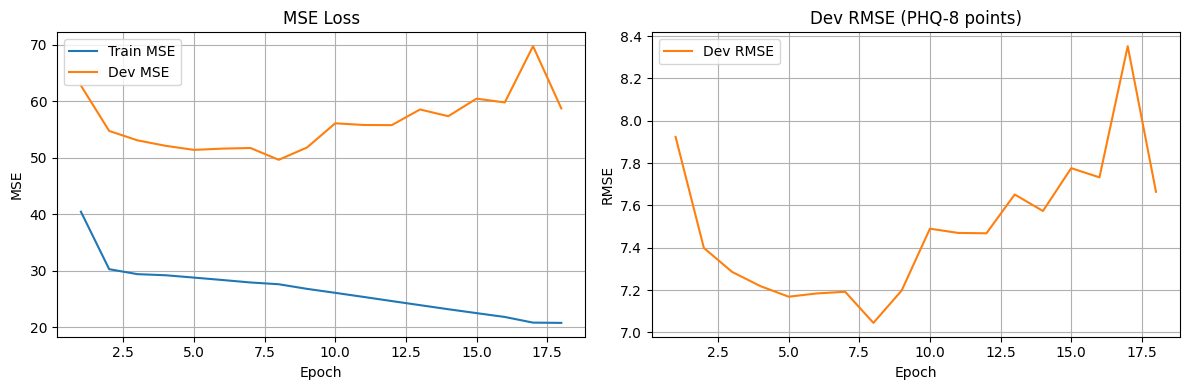

In [11]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train MSE")
axes[0].plot(epochs, history["dev_loss"],   label="Dev MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["dev_rmse"], color="tab:orange", label="Dev RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Dev RMSE (PHQ-8 points)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

Loads the best checkpoint and reports participant-level MSE, RMSE, MAE, and Pearson r.
Each participant's segment predictions are averaged into a single score before computing metrics.

In [12]:
# Load best weights
best_ckpt = torch.load(SAVE_DIR / "cnn_lstm_best.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(dev MSE {best_ckpt['dev_mse']:.4f})")

# Participant-level predictions on test set
_, _, test_agg = evaluate_participant(test_loader)

all_preds  = test_agg["pred"].values
all_labels = test_agg["label"].values

print(f"  Participants evaluated: {len(test_agg)}")

# Metrics
test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results (participant level) ───────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 8  (dev MSE 49.6330)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 41.9473
  RMSE      : 6.4767  PHQ-8 points
  MAE       : 5.4127  PHQ-8 points
  Pearson r : -0.0016


## 7. Prediction Distribution

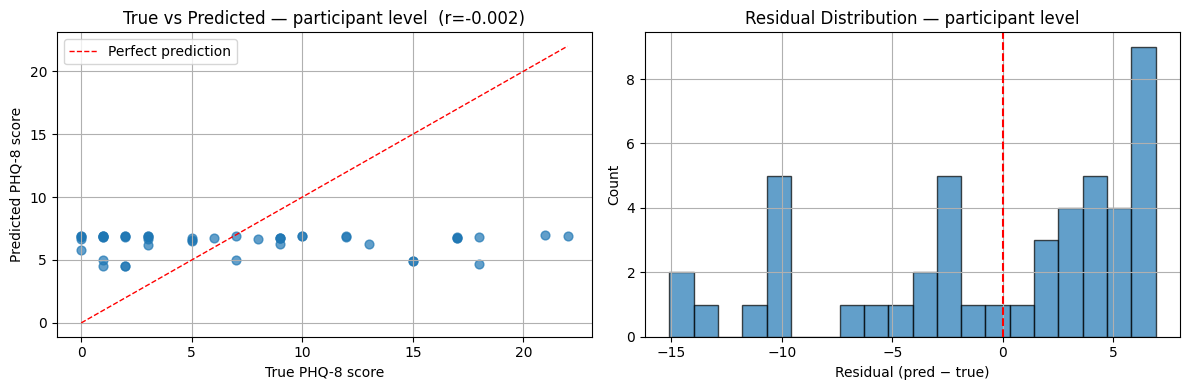

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One point per participant
axes[0].scatter(all_labels, all_preds, alpha=0.7, s=40)
lo, hi = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted — participant level  (r={test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — participant level")
axes[1].grid(True)

plt.tight_layout()
plt.show()